# Exploratory Data Analysis
## CMS Dashboard 4.3 — Unplanned Outages, Charging Sites, and Correlations

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('data')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [63]:
# Use seaborn's pastel palette
PASTEL = sns.color_palette("Accent")

# Map specific colors from the palette
CAT_COLORS = {
    'V2X Chargepoint': PASTEL[3],       # pastel red/pink
    'Building-supplied Charger': PASTEL[0],  # pastel blue
    'Other Chargepoint': PASTEL[2],     # pastel green
}

SEASON_COLORS = [PASTEL[0], PASTEL[2], PASTEL[4], PASTEL[1]]  # Winter, Spring, Summer, Autumn
DUR_CAT_COLORS = [PASTEL[2], PASTEL[4], PASTEL[3], PASTEL[7]]  # <3h, 3-6h, 6-12h, >12h

## 1. Load Data

In [64]:
# Load unplanned outages
outages = pd.read_csv(DATA_DIR / 'df_cleaned.csv')
outages['incident_date_time'] = pd.to_datetime(outages['incident_date_time'], errors='coerce', utc=True)

# Load charging sites
charging = pd.read_csv(DATA_DIR / 'all_charging_sites.csv')

print(f'Outages: {len(outages):,} records, {len(outages.columns)} columns')
print(f'Charging sites: {len(charging)} sites, {len(charging.columns)} columns')

Outages: 11,316 records, 35 columns
Charging sites: 236 sites, 4 columns


## 2. Data Cleaning Analysis
Understanding what cleaning was already done and what remains.

In [65]:
print('=== MISSING VALUES ===')
missing = outages.isnull().sum()
missing_pct = (missing / len(outages) * 100).round(1)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing': missing.values,
    'Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
print(missing_df.to_string(index=False))

print('\n=== CLEANING DECISIONS ===')
print('1. exceptional_event_id (99.6% missing): Kept as-is. Used to derive is_exceptional_event boolean.')
print('2. main_equipment_involved_2-6 (96-98% missing): Not used in analysis. Too sparse for imputation.')
print('3. local_authority (2.9% missing): Kept as-is. Not used in ML model.')
print('4. latitude/longitude (2.9% missing): Kept as-is. Records with NaN coordinates are excluded from spatial analysis.')
print('5. primary_substation (0.2% missing): Kept as-is. Nearest substation distance computed only for cells with valid data.')

=== MISSING VALUES ===
                      Column  Missing  Percentage
        exceptional_event_id    11276        99.6
   exceptional_event_enddate    11276        99.6
exceptional_event_start_date    11276        99.6
   main_equipment_involved_5    11083        97.9
   main_equipment_involved_6    11031        97.5
   main_equipment_involved_4    10918        96.5
   main_equipment_involved_3    10907        96.4
   main_equipment_involved_2    10850        95.9
                   longitude      330         2.9
             local_authority      330         2.9
                    latitude      330         2.9
          primary_substation       23         0.2
          incident_date_time        1         0.0
                        year        1         0.0
                  month_name        1         0.0
                        hour        1         0.0
                      season        1         0.0
          Incident Date-time        1         0.0

=== CLEANING DECISIONS ===

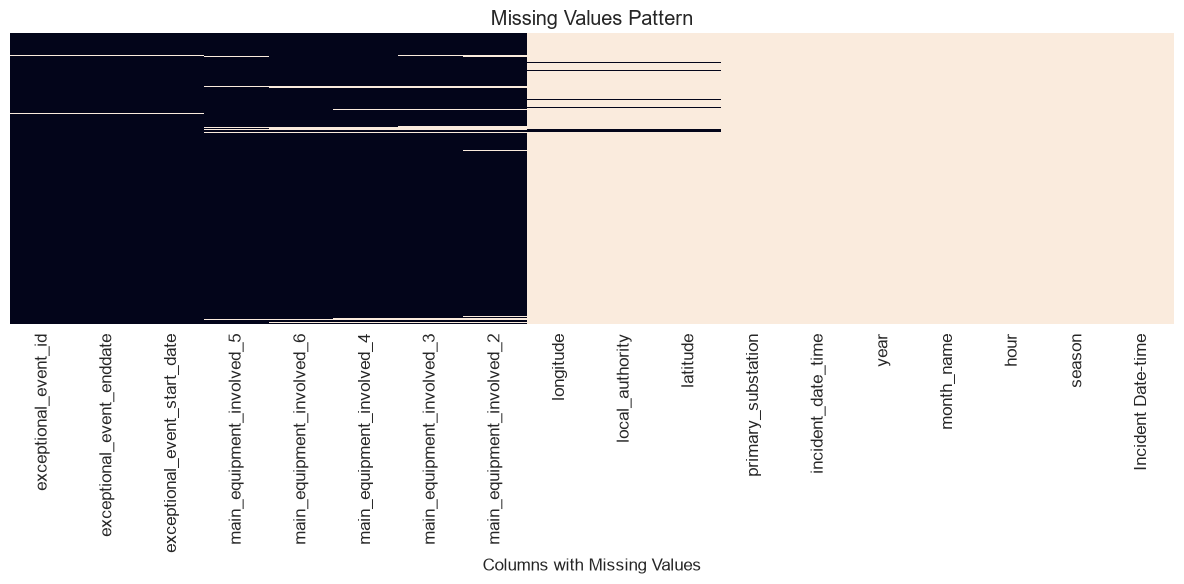

In [66]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 6))

# Only show columns with missing values
cols_with_missing = missing_df['Column'].tolist()
missing_matrix = outages[cols_with_missing].isnull().astype(int)

# Heatmap of missing values (sample for visibility)
sns.heatmap(missing_matrix.__invert__(), 
            cbar=False, yticklabels=False, ax=ax, cmap='rocket')
ax.set_title('Missing Values Pattern')
ax.set_xlabel('Columns with Missing Values')

plt.tight_layout()
plt.savefig('figures/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Outage Data Overview

In [67]:
print('=== DATASET OVERVIEW ===')
print(f'Date range: {outages["incident_date_time"].min()} to {outages["incident_date_time"].max()}')
print(f'Latitude range: {outages["latitude"].min():.2f} to {outages["latitude"].max():.2f}')
print(f'Longitude range: {outages["longitude"].min():.2f} to {outages["longitude"].max():.2f}')
print(f'\nNetwork types:')
for k, v in outages['network_type'].value_counts().items():
    print(f'  {k}: {v:,} ({v/len(outages)*100:.1f}%)')
print(f'\nVoltage levels:')
for k, v in outages['voltage'].value_counts().head(5).items():
    print(f'  {k}: {v:,} ({v/len(outages)*100:.1f}%)')

=== DATASET OVERVIEW ===
Date range: 1997-07-19 08:12:00+00:00 to 2026-07-18 23:27:00+00:00
Latitude range: 53.17 to 55.11
Longitude range: -3.61 to -1.84

Network types:
  LV: 10,818 (95.6%)
  HV: 492 (4.3%)
  KV: 6 (0.1%)

Voltage levels:
  LV: 10,822 (95.6%)
  33: 244 (2.2%)
  11: 210 (1.9%)
  6.6: 34 (0.3%)
  132: 6 (0.1%)


## 4. Duration Distribution

=== DURATION STATISTICS ===
Mean: 9.89 hours
Median: 3.47 hours
Std: 39.33 hours
Min: 0.02 hours
Max: 1391.67 hours
95th percentile: 24.09 hours
99th percentile: 118.69 hours


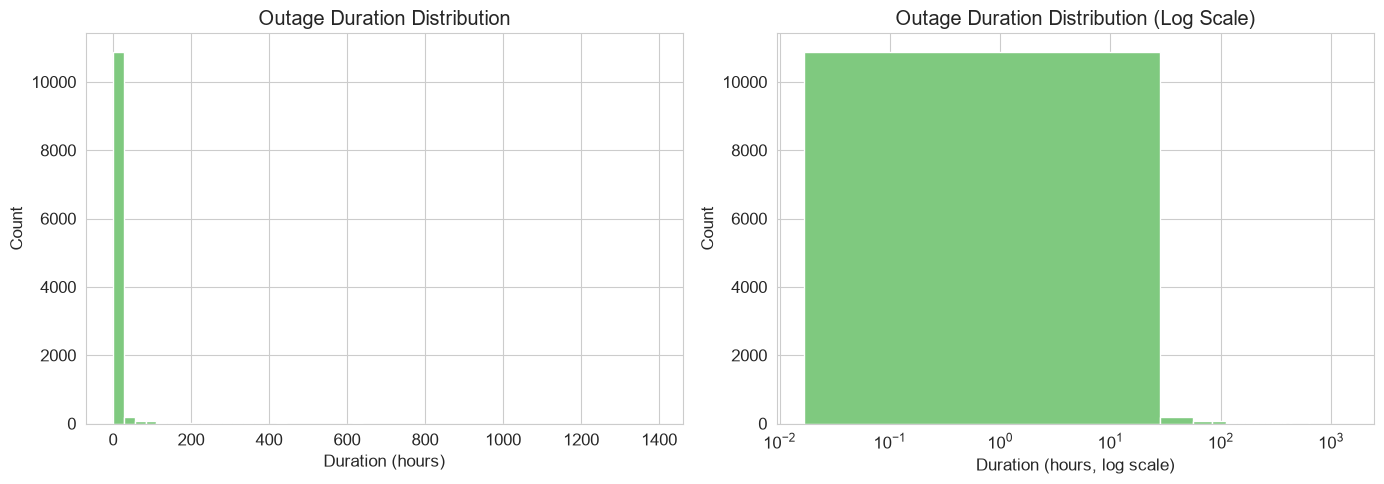

In [68]:
dur = outages['duration-hours'].dropna()

print('=== DURATION STATISTICS ===')
print(f'Mean: {dur.mean():.2f} hours')
print(f'Median: {dur.median():.2f} hours')
print(f'Std: {dur.std():.2f} hours')
print(f'Min: {dur.min():.2f} hours')
print(f'Max: {dur.max():.2f} hours')
print(f'95th percentile: {dur.quantile(0.95):.2f} hours')
print(f'99th percentile: {dur.quantile(0.99):.2f} hours')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(dur, bins=50, color=PASTEL[0], edgecolor='white')
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Count')
axes[0].set_title('Outage Duration Distribution')

# Log-scale histogram
axes[1].hist(dur, bins=50, color=PASTEL[0], edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_xlabel('Duration (hours, log scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Outage Duration Distribution (Log Scale)')

plt.tight_layout()
plt.savefig('figures/duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

=== UPPER PERCENTILE DURATION ANALYSIS ===

--- 90th percentile (≥16.6 hours) ---
Count: 1,135 (10.0%)
Top causes:
  Companies: 816 (71.9%)
  Weather and Environment: 147 (13.0%)
  Unclassified or Unknown: 96 (8.5%)
  Third Party: 74 (6.5%)
  Birds, Animals and Insects: 2 (0.2%)

--- 95th percentile (≥24.1 hours) ---
Count: 566 (5.0%)
Top causes:
  Companies: 384 (67.8%)
  Weather and Environment: 93 (16.4%)
  Unclassified or Unknown: 54 (9.5%)
  Third Party: 33 (5.8%)
  Birds, Animals and Insects: 2 (0.4%)

--- 99th percentile (≥118.7 hours) ---
Count: 114 (1.0%)
Top causes:
  Companies: 77 (67.5%)
  Unclassified or Unknown: 24 (21.1%)
  Weather and Environment: 11 (9.6%)
  Third Party: 2 (1.8%)


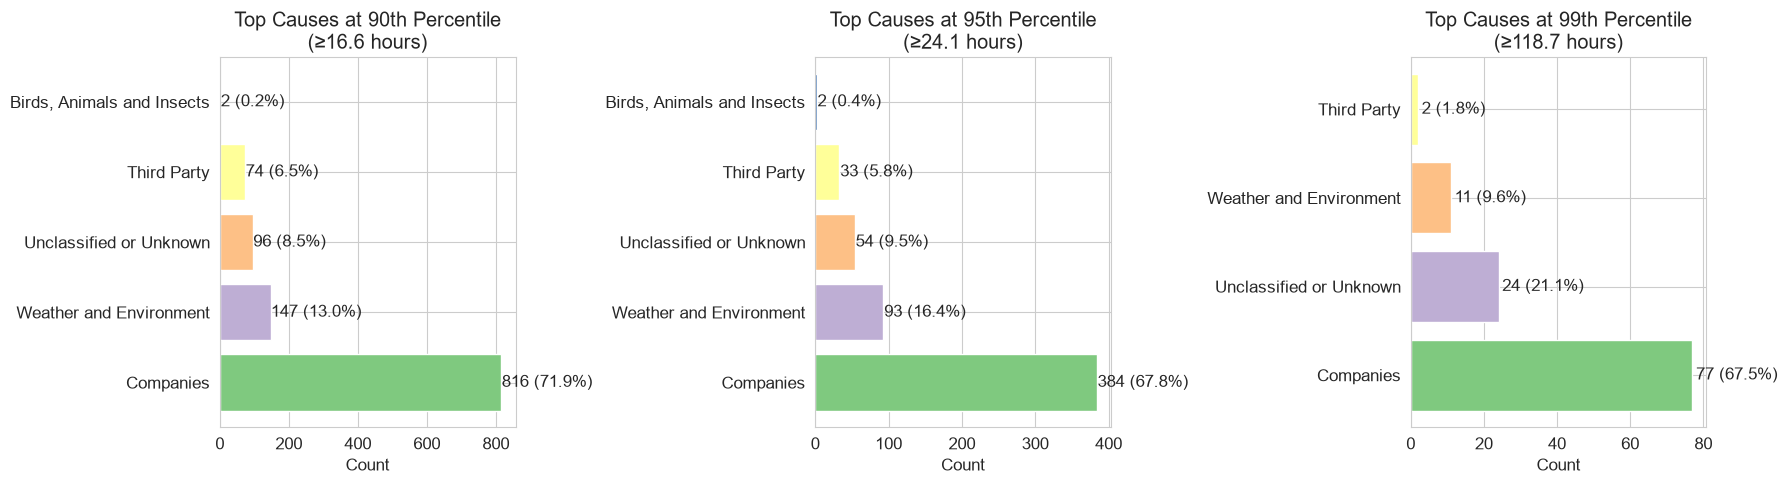

In [69]:
# Upper percentile analysis - what causes extreme outages?
dur = outages['duration-hours'].dropna()

percentiles = [90, 95, 99]
print('=== UPPER PERCENTILE DURATION ANALYSIS ===')
for p in percentiles:
    threshold = dur.quantile(p/100)
    upper = outages[outages['duration-hours'] >= threshold]
    print(f'\n--- {p}th percentile (≥{threshold:.1f} hours) ---')
    print(f'Count: {len(upper):,} ({len(upper)/len(outages)*100:.1f}%)')
    print(f'Top causes:')
    for cause, count in upper['direct_cause_category'].value_counts().head(5).items():
        print(f'  {cause}: {count} ({count/len(upper)*100:.1f}%)')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, p in enumerate(percentiles):
    threshold = dur.quantile(p/100)
    upper = outages[outages['duration-hours'] >= threshold]
    cause_counts = upper['direct_cause_category'].value_counts()
    
    axes[i].barh(cause_counts.index, cause_counts.values, color=PASTEL)
    axes[i].set_xlabel('Count')
    axes[i].set_title(f'Top Causes at {p}th Percentile\n(≥{threshold:.1f} hours)')
    for j, v in enumerate(cause_counts.values):
        axes[i].text(v + 1, j, f'{v} ({v/len(upper)*100:.1f}%)', va='center')

plt.tight_layout()
plt.savefig('figures/upper_percentile_causes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Temporal Distribution

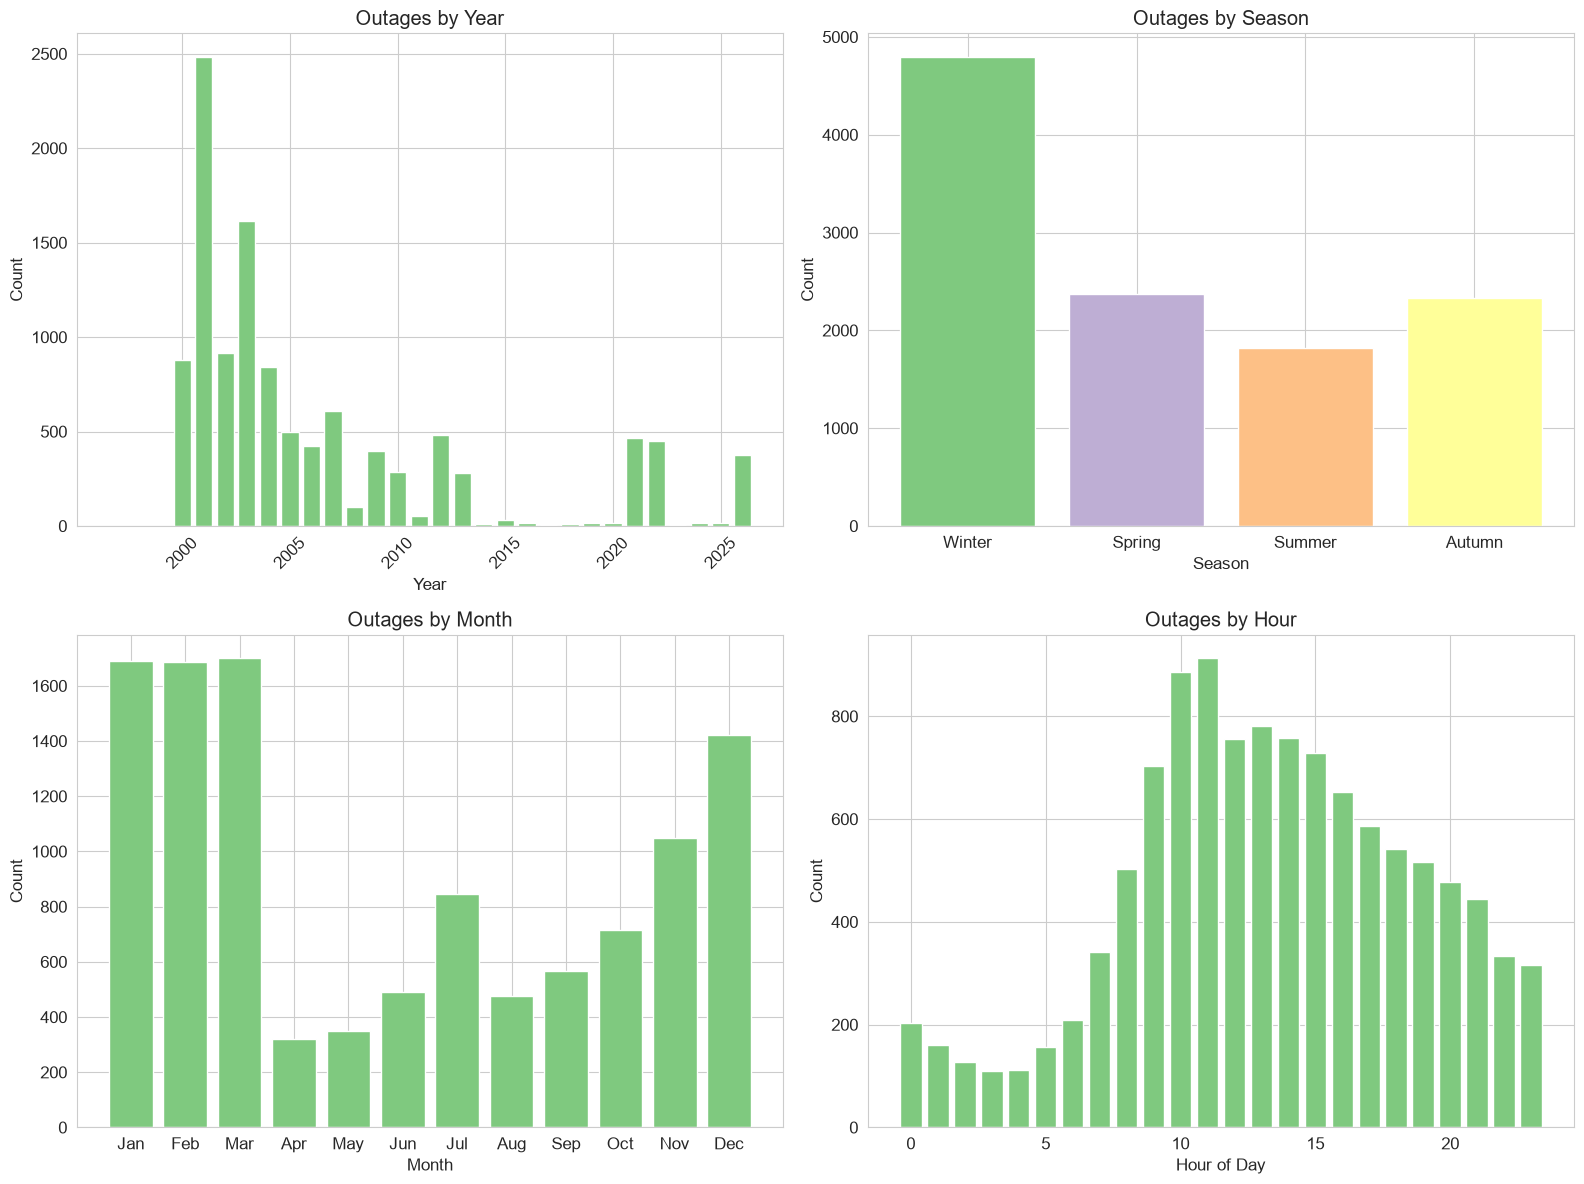

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# By year
year_counts = outages['year'].value_counts().sort_index()
axes[0, 0].bar(year_counts.index, year_counts.values, color=PASTEL[0])
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Outages by Year')
axes[0, 0].tick_params(axis='x', rotation=45)

# By season
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_counts = outages['season'].value_counts().reindex(season_order)
axes[0, 1].bar(season_counts.index,  season_counts.values, color=PASTEL)
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Outages by Season')

# By month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = outages['month_name'].value_counts().reindex(month_order)
axes[1, 0].bar(range(12), month_counts.values, color=PASTEL[0])
axes[1, 0].set_xticks(range(12))
axes[1, 0].set_xticklabels([m[:3] for m in month_order])
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Outages by Month')

# By hour
hour_counts = outages['hour'].value_counts().sort_index()
axes[1, 1].bar(hour_counts.index, hour_counts.values, color=PASTEL[0])
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Outages by Hour')

plt.tight_layout()
plt.savefig('figures/temporal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cause Analysis

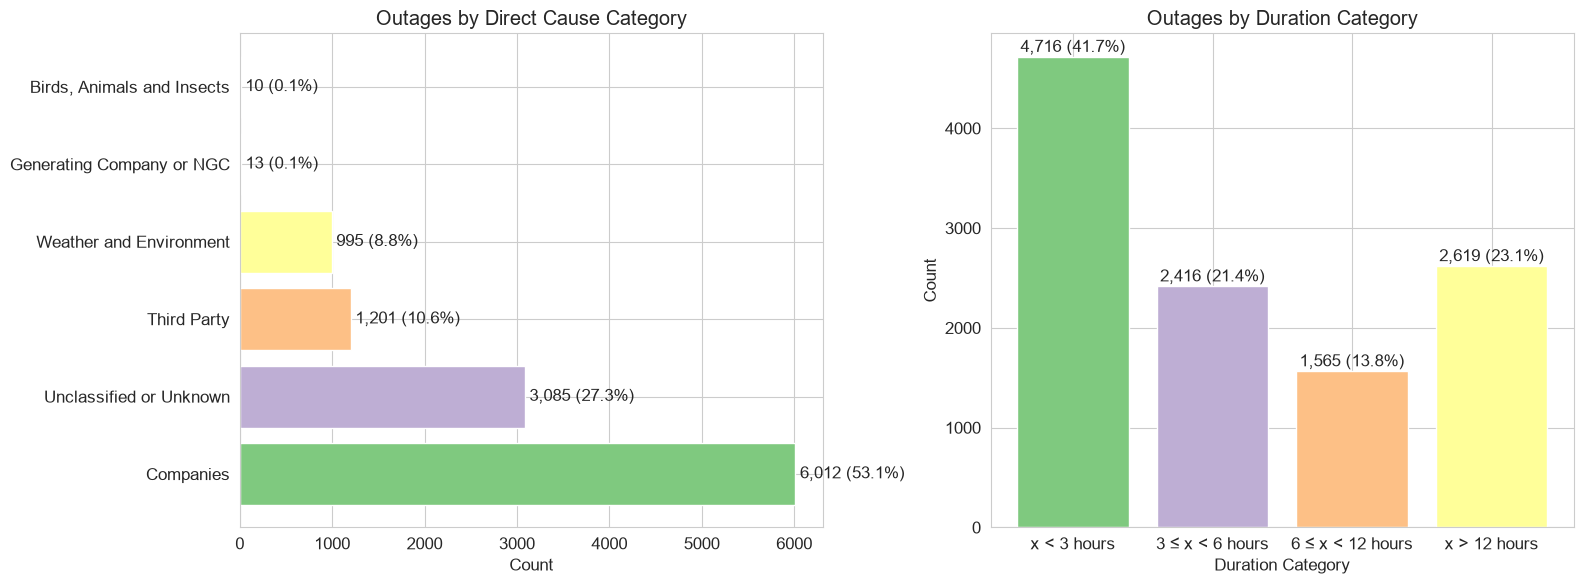

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Direct cause category
cause_counts = outages['direct_cause_category'].value_counts()
axes[0].barh(cause_counts.index, cause_counts.values, color=PASTEL)
axes[0].set_xlabel('Count')
axes[0].set_title('Outages by Direct Cause Category')
for i, v in enumerate(cause_counts.values):
    axes[0].text(v + 50, i, f'{v:,} ({v/len(outages)*100:.1f}%)', va='center')

# Duration category
dur_cat_order = ['x < 3 hours', '3 ≤ x < 6 hours', '6 ≤ x < 12 hours', 'x > 12 hours']
dur_cat_counts = outages['duration_category'].value_counts().reindex(dur_cat_order)
axes[1].bar(dur_cat_counts.index, dur_cat_counts.values, color=PASTEL)
axes[1].set_xlabel('Duration Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Outages by Duration Category')
for i, v in enumerate(dur_cat_counts.values):
    axes[1].text(i, v + 50, f'{v:,} ({v/len(outages)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.savefig('figures/cause_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

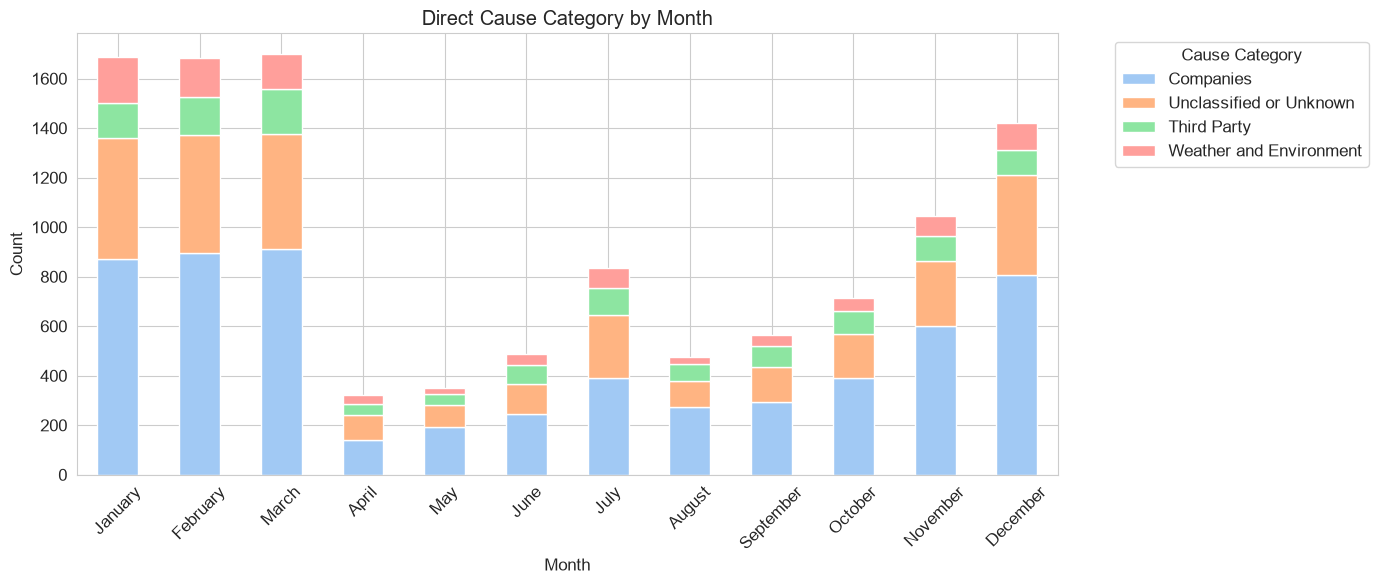

In [81]:
# Cause by month - stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Get top 4 causes
top_causes = outages['direct_cause_category'].value_counts().head(4).index.tolist()

# Pivot table: month x cause
cause_by_month = outages[outages['direct_cause_category'].isin(top_causes)].groupby(
    ['month_name', 'direct_cause_category']).size().unstack(fill_value=0)
cause_by_month = cause_by_month.reindex(month_order)

# Plot stacked bar
cause_by_month[top_causes].plot(kind='bar', stacked=True, ax=ax, 
                                 color=sns.color_palette("pastel", len(top_causes)))
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_title('Direct Cause Category by Month')
ax.legend(title='Cause Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/cause_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

=== CONTINGENCY TABLE (Month x Cause) ===
direct_cause_category  Birds, Animals and Insects  Companies  \
month_name                                                     
January                                         0        870   
February                                        0        896   
March                                           1        912   
April                                           0        142   
May                                             1        193   
June                                            1        246   
July                                            5        389   
August                                          1        273   
September                                       0        293   
October                                         0        392   
November                                        1        599   
December                                        0        806   

direct_cause_category  Generating Company or NGC  Third Party

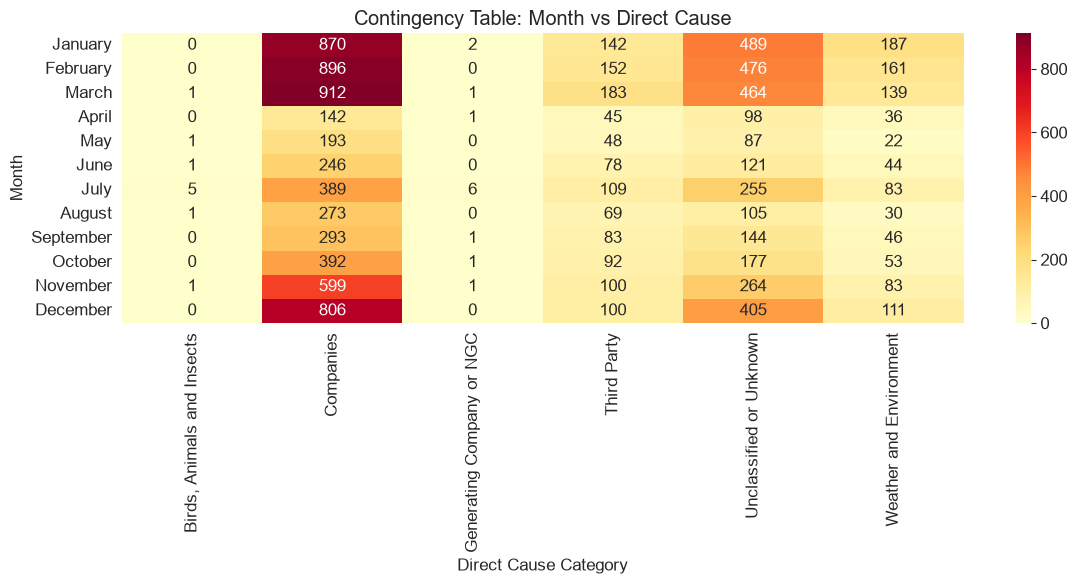

In [ ]:
# Correlation between direct cause and month
from scipy.stats import chi2_contingency
import numpy as np

# Contingency table
contingency = pd.crosstab(outages['month_name'], outages['direct_cause_category'])

# Reorder months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
contingency = contingency.reindex(month_order)

print('=== CONTINGENCY TABLE (Month x Cause) ===')
print(contingency)

# Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency)
print(f'\n=== CHI-SQUARED TEST ===')
print(f'Chi-squared: {chi2:.2f}')
print(f'p-value: {p:.6f}')
print(f'Degrees of freedom: {dof}')
print(f'Significant: {"Yes" if p < 0.05 else "No"} (alpha=0.05)')

# Cramér's V (effect size)
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f'\nCramér\'s V: {cramers_v:.3f}')
print(f'Effect size: {"Weak" if cramers_v < 0.1 else "Small" if cramers_v < 0.3 else "Medium" if cramers_v < 0.5 else "Strong"}')

# Heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('Direct Cause Category')
ax.set_ylabel('Month')
ax.set_title('Contingency Table: Month vs Direct Cause')

plt.tight_layout()
plt.savefig('figures/cause_month_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Spatial Distribution (Interactive Map)

In [72]:
import folium
from folium.plugins import HeatMap

# Create base map centered on ENWL area
center_lat = outages['latitude'].mean()
center_lon = outages['longitude'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles='CartoDB positron')

# Add outage heatmap
heat_data = outages[['latitude', 'longitude', 'duration-hours']].dropna()
HeatMap(
    data=heat_data[['latitude', 'longitude', 'duration-hours']].values.tolist(),
    radius=10,
    blur=15,
    max_zoom=10,
    name='Outage Heatmap'
).add_to(m)

# Add charging sites
for _, site in charging.iterrows():
    color_map = {
        'V2X Chargepoint': 'red',
        'Building-supplied Charger': 'blue',
        'Other Chargepoint': 'green'
    }
    color = color_map.get(site['site_category'], 'gray')
    
    folium.CircleMarker(
        location=[site['latitude'], site['longitude']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"<b>{site['charge_point_location']}</b><br>{site['site_category']}",
        tooltip=site['charge_point_location'],
    ).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Add legend
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; 
     background: white; padding: 10px; border: 2px solid grey; border-radius: 5px;">
<b>Legend</b><br>
<i style="background: red; width: 12px; height: 12px; display: inline-block;"></i> V2X Chargepoint<br>
<i style="background: blue; width: 12px; height: 12px; display: inline-block;"></i> Building-supplied Charger<br>
<i style="background: green; width: 12px; height: 12px; display: inline-block;"></i> Other Chargepoint<br>
<i style="background: orange; width: 12px; height: 12px; display: inline-block;"></i> Outage Heatmap
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save map
m.save('figures/spatial_map.html')
print('Map saved to figures/spatial_map.html')

# Display in notebook
m

Map saved to figures/spatial_map.html


## 8. Charging Sites Analysis

=== CHARGING SITES ===
Total sites: 236

By category:
  Other Chargepoint: 199 (84.3%)
  Building-supplied Charger: 24 (10.2%)
  V2X Chargepoint: 13 (5.5%)


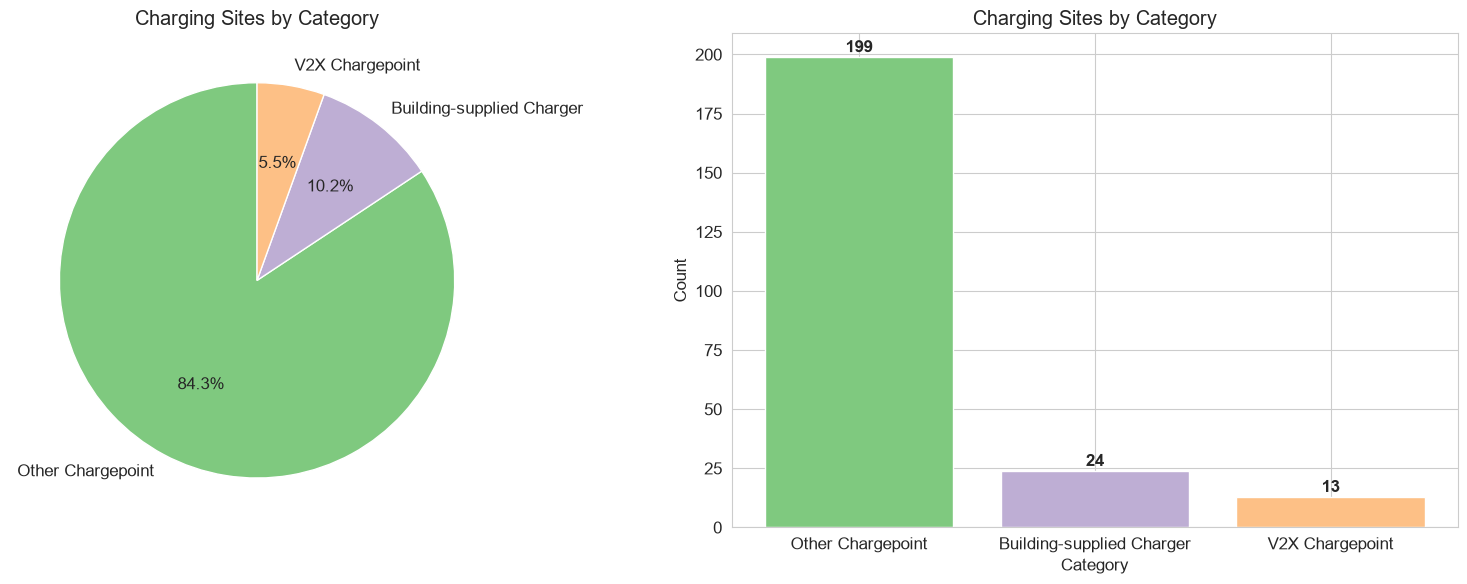

In [73]:
print('=== CHARGING SITES ===')
print(f'Total sites: {len(charging)}')
print(f'\nBy category:')
for cat, count in charging['site_category'].value_counts().items():
    print(f'  {cat}: {count} ({count/len(charging)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
cat_counts = charging['site_category'].value_counts()
wedges, texts, autotexts = axes[0].pie(
    cat_counts.values, 
    labels=cat_counts.index, 
    autopct='%1.1f%%',
    colors=PASTEL,
    startangle=90
)
axes[0].set_title('Charging Sites by Category')

# Bar chart with counts
axes[1].bar(cat_counts.index, cat_counts.values, color=PASTEL)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Charging Sites by Category')
for i, v in enumerate(cat_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/charging_sites_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. District Analysis

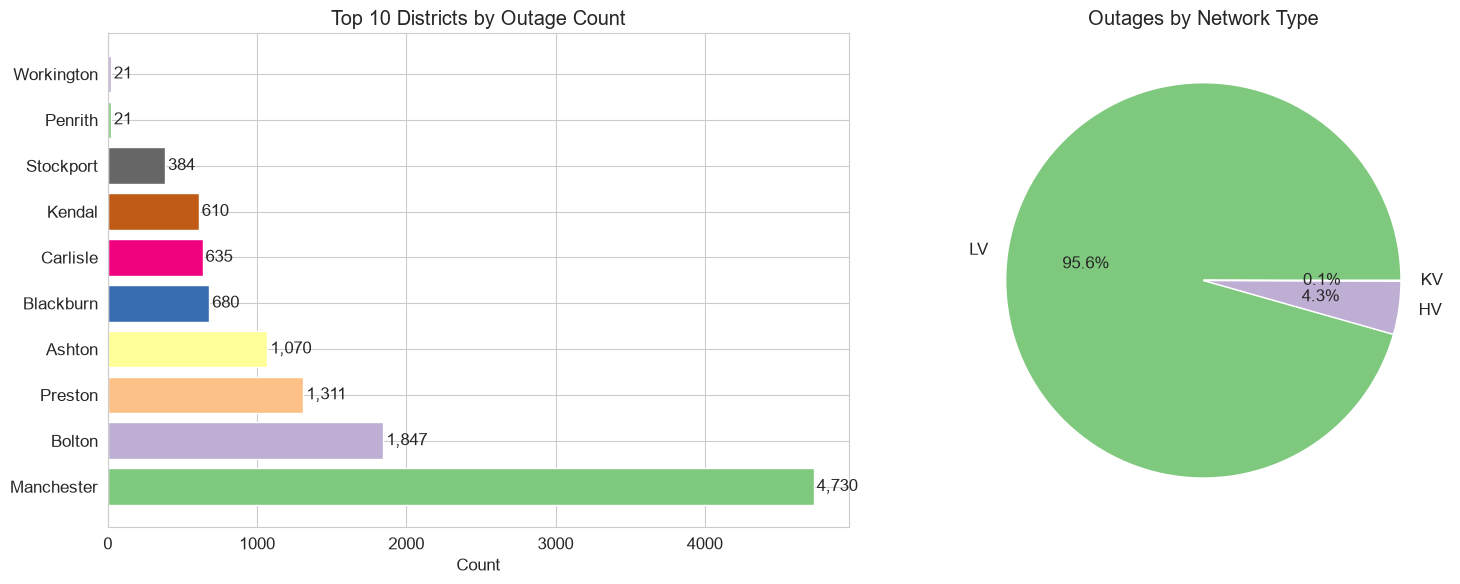

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top districts
dist_counts = outages['district_name'].value_counts().head(10)
axes[0].barh(dist_counts.index, dist_counts.values, color=PASTEL)
axes[0].set_xlabel('Count')
axes[0].set_title('Top 10 Districts by Outage Count')
for i, v in enumerate(dist_counts.values):
    axes[0].text(v + 20, i, f'{v:,}', va='center')

# Network type
net_counts = outages['network_type'].value_counts()
axes[1].pie(net_counts.values, labels=net_counts.index, autopct='%1.1f%%', 
           colors=PASTEL)
axes[1].set_title('Outages by Network Type')

plt.tight_layout()
plt.savefig('figures/district_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Customer Impact

=== CUSTOMER IMPACT ===
Total customer minutes lost: 169,310,107
Mean: 14,962
Median: 582
Max: 38,100,650


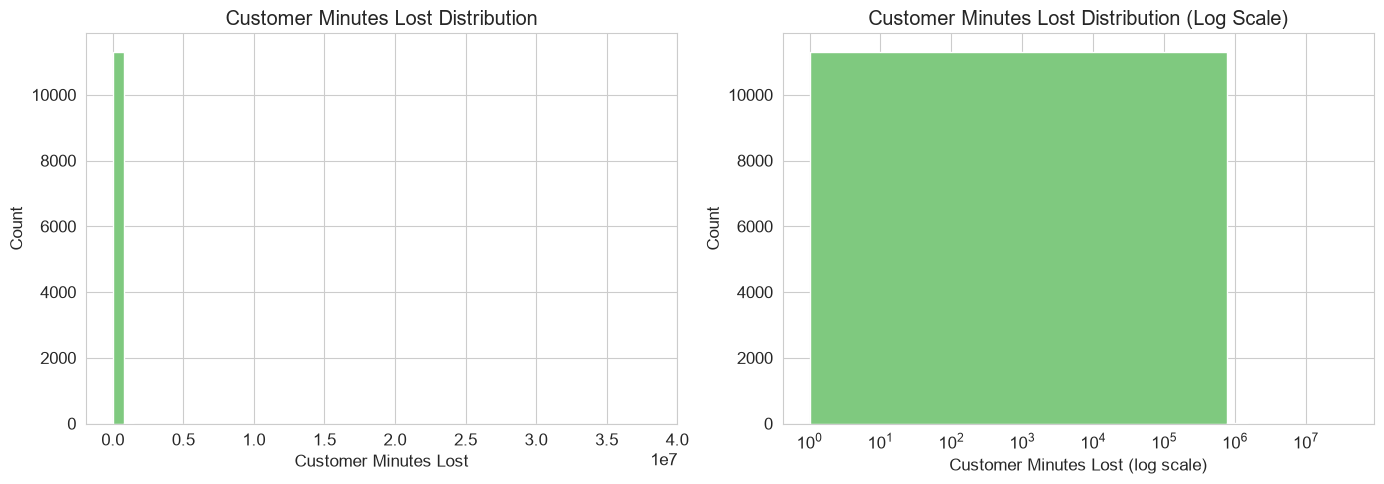

In [75]:
cust = outages['total_customer_minutes_lost'].dropna()

print('=== CUSTOMER IMPACT ===')
print(f'Total customer minutes lost: {cust.sum():,.0f}')
print(f'Mean: {cust.mean():,.0f}')
print(f'Median: {cust.median():,.0f}')
print(f'Max: {cust.max():,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(cust, bins=50, color=PASTEL[0], edgecolor='white')
axes[0].set_xlabel('Customer Minutes Lost')
axes[0].set_ylabel('Count')
axes[0].set_title('Customer Minutes Lost Distribution')

# Log scale
axes[1].hist(cust, bins=50, color=PASTEL[0], edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_xlabel('Customer Minutes Lost (log scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Customer Minutes Lost Distribution (Log Scale)')

plt.tight_layout()
plt.savefig('figures/customer_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Feature Correlation

In [76]:
# Compute grid-cell features for correlation analysis
cell_size = 0.02
outages['cell_lat'] = (outages['latitude'] / cell_size).round() * cell_size
outages['cell_lon'] = (outages['longitude'] / cell_size).round() * cell_size

# Cap duration at 168 hours
outages['duration_capped'] = outages['duration-hours'].clip(upper=168)

# Temporal flags
outages['month'] = outages['incident_date_time'].dt.month
outages['is_winter'] = outages['month'].isin([12, 1, 2])
outages['is_night'] = (outages['hour'] >= 22) | (outages['hour'] < 6)
outages['is_exceptional'] = outages['is_exceptional_event'].fillna(False).astype(bool)

# Aggregate by cell
cell_features = outages.groupby(['cell_lat', 'cell_lon']).agg(
    outage_count=('duration_capped', 'size'),
    avg_duration=('duration_capped', 'mean'),
    std_duration=('duration_capped', 'std'),
    total_customer_hours=('total_customer_minutes_lost', lambda x: x.sum() / 60),
    max_duration=('duration_capped', 'max'),
    winter_ratio=('is_winter', 'mean'),
    night_ratio=('is_night', 'mean'),
    exceptional_ratio=('is_exceptional', 'mean'),
    cause_diversity=('direct_cause_category', 'nunique'),
).reset_index()

cell_features['std_duration'] = cell_features['std_duration'].fillna(0)
cell_features['log_avg_duration'] = np.log1p(cell_features['avg_duration'])
cell_features['log_total_customer_hours'] = np.log1p(cell_features['total_customer_hours'])

print(f'Grid cells: {len(cell_features)}')
print(f'Features: {len(cell_features.columns) - 2}')

Grid cells: 1425
Features: 11


In [86]:
# Compute nearest_substation_km
from math import radians, cos, sin, atan2, sqrt

def haversine_km(lat1, lon1, lat2_arr, lon2_arr):
    R = 6371.0
    lat1_r, lon1_r = radians(lat1), radians(lon1)
    lat2_r, lon2_r = np.radians(lat2_arr), np.radians(lon2_arr)
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = np.sin(dlat / 2) ** 2 + cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Get substation locations from outages
substation_locs = outages.dropna(subset=['primary_substation']).groupby('primary_substation')[['latitude', 'longitude']].mean().values

nearest_substation_km = []
for _, row in cell_features.iterrows():
    dists = haversine_km(row['cell_lat'], row['cell_lon'], substation_locs[:, 0], substation_locs[:, 1])
    nearest_substation_km.append(float(dists.min()))
cell_features['nearest_substation_km'] = nearest_substation_km

# Compute neighbor_outage_count
cell_counts = cell_features.set_index(['cell_lat', 'cell_lon'])['outage_count'].to_dict()
neighbor_counts = []
for _, row in cell_features.iterrows():
    total = 0
    for dlat in [-cell_size, 0, cell_size]:
        for dlon in [-cell_size, 0, cell_size]:
            if dlat == 0 and dlon == 0:
                continue
            key = (round(row['cell_lat'] + dlat, 6), round(row['cell_lon'] + dlon, 6))
            if key in cell_counts:
                total += cell_counts[key]
    neighbor_counts.append(total)
cell_features['neighbor_outage_count'] = neighbor_counts

print(f'Added nearest_substation_km and neighbor_outage_count')
print(f'Total features: 13')

Added nearest_substation_km and neighbor_outage_count
Total features: 13


In [87]:
# Get substation locations from outages (filter out NaN coordinates)
substation_locs = outages.dropna(subset=['primary_substation', 'latitude', 'longitude']).groupby('primary_substation')[['latitude', 'longitude']].mean()

# Filter out substations with NaN coordinates
substation_locs = substation_locs.dropna(subset=['latitude', 'longitude'])
sub_coords = substation_locs.values

print(f'Substation locations with valid coordinates: {len(substation_locs)}')

# Compute nearest substation distance
nearest_substation_km = []
for _, row in cell_features.iterrows():
    dists = haversine_km(row['cell_lat'], row['cell_lon'], sub_coords[:, 0], sub_coords[:, 1])
    nearest_substation_km.append(float(dists.min()))
cell_features['nearest_substation_km'] = nearest_substation_km

print(f'nearest_substation_km computed: {len(nearest_substation_km)}')
print(f'NaN count: {pd.Series(nearest_substation_km).isna().sum()}')

Substation locations with valid coordinates: 5955
nearest_substation_km computed: 1425
NaN count: 0


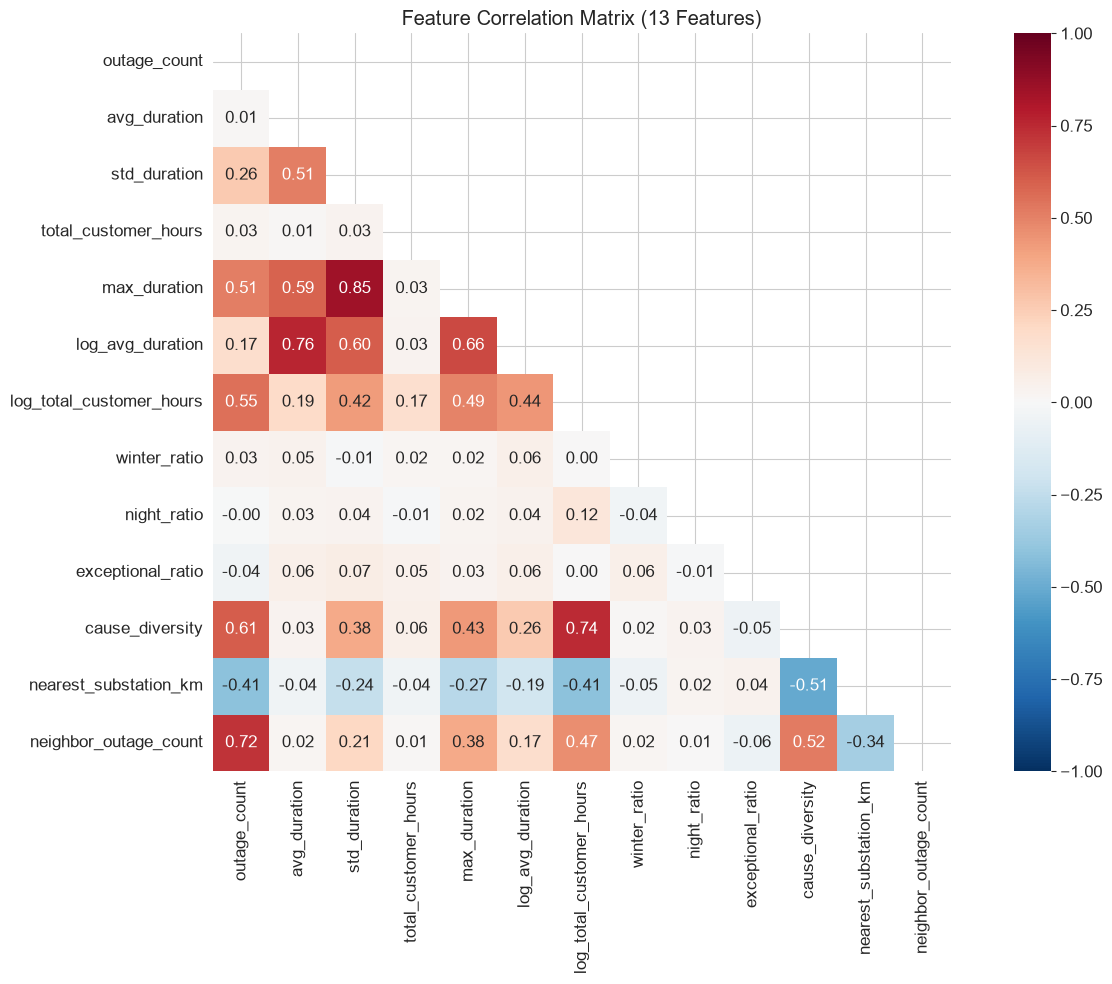

                          outage_count  avg_duration  std_duration  total_customer_hours  max_duration  log_avg_duration  log_total_customer_hours  winter_ratio  night_ratio  exceptional_ratio  cause_diversity  nearest_substation_km  neighbor_outage_count
outage_count                      1.00          0.01          0.26                  0.03          0.51              0.17                      0.55          0.03        -0.00              -0.04             0.61                  -0.41                   0.72
avg_duration                      0.01          1.00          0.51                  0.01          0.59              0.76                      0.19          0.05         0.03               0.06             0.03                  -0.04                   0.02
std_duration                      0.26          0.51          1.00                  0.03          0.85              0.60                      0.42         -0.01         0.04               0.07             0.38                  -0.24

In [88]:
# Correlation matrix (all 13 features)
feature_cols = ['outage_count', 'avg_duration', 'std_duration', 'total_customer_hours',
                'max_duration', 'log_avg_duration', 'log_total_customer_hours',
                'winter_ratio', 'night_ratio', 'exceptional_ratio', 'cause_diversity',
                'nearest_substation_km', 'neighbor_outage_count']

corr = cell_features[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix (13 Features)')

plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print for verification
print(corr.round(2).to_string())

## 12. Outages Near Charging Sites

In [78]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1_r, lon1_r = radians(lat1), radians(lon1)
    lat2_r, lon2_r = np.radians(lat2), np.radians(lon2)
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = np.sin(dlat / 2) ** 2 + cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Count outages within 2 miles (3.218 km) of each charging site
radius_km = 3.218
results = []

for _, site in charging.iterrows():
    dists = haversine_km(site['latitude'], site['longitude'], 
                        outages['latitude'].values, outages['longitude'].values)
    nearby = outages[dists <= radius_km]
    results.append({
        'site_name': site['charge_point_location'],
        'category': site['site_category'],
        'lat': site['latitude'],
        'lon': site['longitude'],
        'nearby_outages': len(nearby),
        'nearby_hours': nearby['duration-hours'].sum() if len(nearby) > 0 else 0,
    })

site_outages = pd.DataFrame(results)

print('=== OUTAGES NEAR CHARGING SITES ===')
print(f'Total sites: {len(site_outages)}')
print(f'Sites with nearby outages: {(site_outages["nearby_outages"] > 0).sum()}')
print(f'\nBy category:')
for cat in ['V2X Chargepoint', 'Building-supplied Charger', 'Other Chargepoint']:
    mask = site_outages['category'] == cat
    print(f'  {cat}:')
    print(f'    Sites: {mask.sum()}')
    print(f'    Mean outages nearby: {site_outages.loc[mask, "nearby_outages"].mean():.1f}')
    print(f'    Mean hours nearby: {site_outages.loc[mask, "nearby_hours"].mean():.1f}')

=== OUTAGES NEAR CHARGING SITES ===
Total sites: 236
Sites with nearby outages: 208

By category:
  V2X Chargepoint:
    Sites: 13
    Mean outages nearby: 10.0
    Mean hours nearby: 113.9
  Building-supplied Charger:
    Sites: 24
    Mean outages nearby: 13.3
    Mean hours nearby: 118.5
  Other Chargepoint:
    Sites: 199
    Mean outages nearby: 27.7
    Mean hours nearby: 255.1


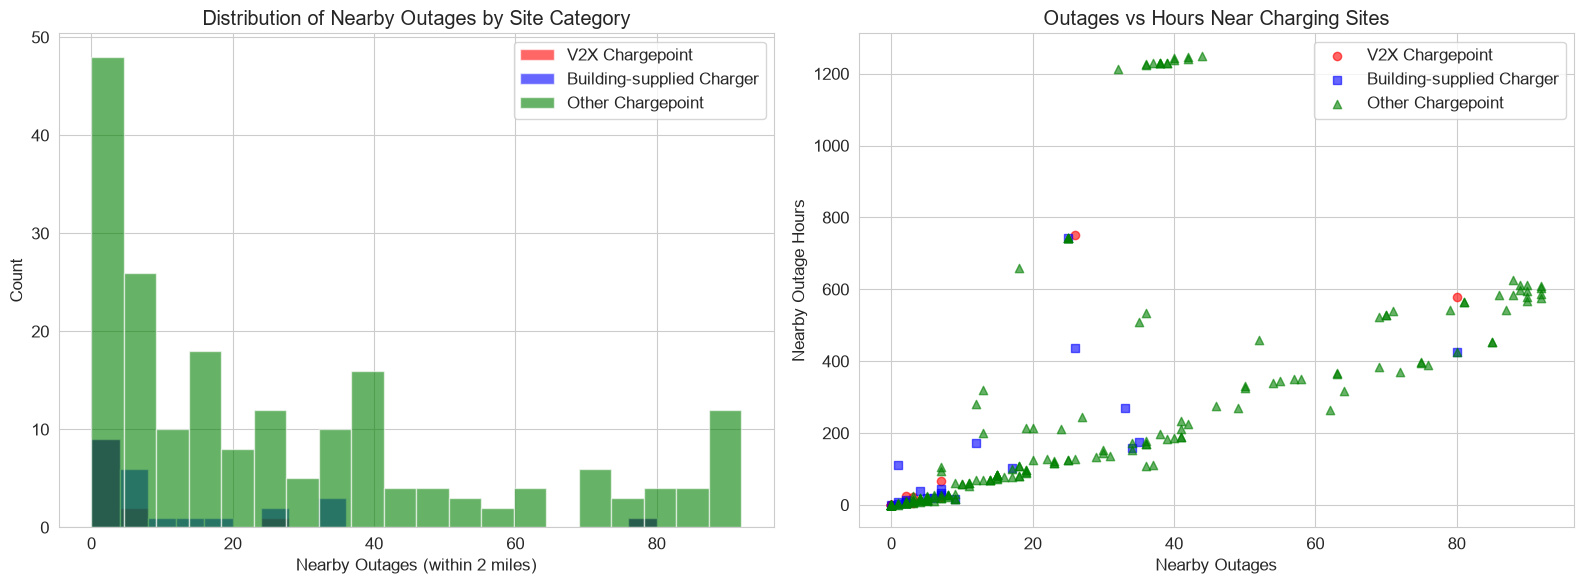

In [79]:
# Plot outages near charging sites
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By category
for cat, color in [('V2X Chargepoint', 'red'), 
                    ('Building-supplied Charger', 'blue'), 
                    ('Other Chargepoint', 'green')]:
    mask = site_outages['category'] == cat
    axes[0].hist(site_outages.loc[mask, 'nearby_outages'], bins=20, alpha=0.6, 
                color=color, label=cat)
axes[0].set_xlabel('Nearby Outages (within 2 miles)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Nearby Outages by Site Category')
axes[0].legend()

# Scatter: outages vs hours
for cat, color, marker in [('V2X Chargepoint', 'red', 'o'), 
                            ('Building-supplied Charger', 'blue', 's'), 
                            ('Other Chargepoint', 'green', '^')]:
    mask = site_outages['category'] == cat
    axes[1].scatter(site_outages.loc[mask, 'nearby_outages'], 
                   site_outages.loc[mask, 'nearby_hours'],
                   c=color, marker=marker, label=cat, alpha=0.6)
axes[1].set_xlabel('Nearby Outages')
axes[1].set_ylabel('Nearby Outage Hours')
axes[1].set_title('Outages vs Hours Near Charging Sites')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/outages_near_sites.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Summary Statistics

In [80]:
print('=' * 60)
print('SUMMARY STATISTICS FOR DISSERTATION')
print('=' * 60)

print('\n--- Unplanned Outages ---')
print(f'Records: {len(outages):,}')
print(f'Date range: {outages["incident_date_time"].min().strftime("%Y-%m-%d")} to {outages["incident_date_time"].max().strftime("%Y-%m-%d")}')
print(f'Grid cells: {len(cell_features)}')
print(f'Duration: mean={dur.mean():.1f}h, median={dur.median():.1f}h')
print(f'Winter outages: {outages["season"].value_counts()["Winter"]:,} ({outages["season"].value_counts()["Winter"]/len(outages)*100:.1f}%)')

print('\n--- Charging Sites ---')
print(f'Total sites: {len(charging)}')
for cat, count in charging['site_category'].value_counts().items():
    print(f'  {cat}: {count}')

print('\n--- Correlations (top 5) ---')
corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        corr_pairs.append((feature_cols[i], feature_cols[j], corr.iloc[i, j]))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for f1, f2, c in corr_pairs[:5]:
    print(f'  {f1} vs {f2}: {c:.3f}')

SUMMARY STATISTICS FOR DISSERTATION

--- Unplanned Outages ---
Records: 11,316
Date range: 1997-07-19 to 2026-07-18
Grid cells: 1425
Duration: mean=9.9h, median=3.5h
Winter outages: 4,797 (42.4%)

--- Charging Sites ---
Total sites: 236
  Other Chargepoint: 199
  Building-supplied Charger: 24
  V2X Chargepoint: 13

--- Correlations (top 5) ---
  std_duration vs max_duration: 0.848
  avg_duration vs log_avg_duration: 0.763
  log_total_customer_hours vs cause_diversity: 0.744
  max_duration vs log_avg_duration: 0.660
  outage_count vs cause_diversity: 0.607
